In [1]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
from typing import List, Tuple
import seaborn as sns

from tqdm import tqdm

import pickle

import spacy as sp
import re
import emoji
from spacy.matcher import Matcher

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report


from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
pd.set_option("max_colwidth", None)
df = pd.read_csv('Russian dataset for the reply recovery/final_complete/train_data.csv')
df.head()

,Unnamed: 0,premise,hypothesis,label,chat
0,0,И изи,А если третий?,1,terrariaphone
1,1,"хз, машина твоя подойдет я думаю",хааааа!!! ))) даж в проекте цобакенов на газонах выгуливают))),1,orange_sosedi
2,2,Лови,Всем похуй,1,terrariaphone
3,3,"Добрый день! Дочке 5 лет, не выговаривает звуки к-г и л. В логогруппу нас не взяли. Весной мы пошли к логопеду. Она категорически не хочет заниматься, грубит, вредничает, были у двух логопедов, так с обоими. И вообще есть особенность - любит хвастать, но если есть в чем-то милейшая трудность, дочка избегает такое дело. Что можно сделать в нашей ситуации. К-г и л к пяти годам уже должны были встать, и старшие дети во дворе бывает дразнятся. До пяти лет я по поводу звуков и не ""лезла"" к дочке",Ларец знаний. Как-то была реклама недавно что там бесплатный прием логопеда,0,sling38
4,4,"Я когда заезжала, думала что оп будет охраняемый) потому что сколько раз была в гостях в новостройках, чаще всего там была пропускная система. Потом уже выяснила)","Купили квартиру, не изучив проект? Вы смелая 😄",0,orange_sosedi


In [3]:
nlp = sp.load("ru_core_news_sm")

In [4]:
remove_start = {"а", "кстати", "то"}
negative_ptr = {"это", "там", "ты", "тут", "вот"}
negative_connectors = {"или", "и", "вы", "ну", "так", "да", "разве", "о"}
positive_words = {"подскажите", "подскажи", "ребят", "ребята", "коллеги", "друзья",
                  "кто-нибудь", "всем", "кто-то", "привет", "здравствуйте", "доброго"}
positive_combinations = { "если", "может", "я", "не", "можно", "в", "никто", "можете", "у" }
uncertain = {"на", "с", "интересно", "для", "мне"}
question_words = {"как", "что", "сколько", "где", "какой", "кто", "когда",
                  "почему", "чем", "чего", "куда", "который", "кому", "зачем",
                  "откуда", "чей", "чья", "каков", "отчего"}

pattern_esli_to = [{'LOWER': 'если'},
                        {'OP': '*'},
                        {'LOWER': 'то'}]

pattern_ya_verno = [{'LOWER': 'я'},
                        {'OP': '*'},
                        {'LOWER': 'верно'}]

pattern_ya_ponyal = [{'LOWER': 'я'},
                     {'OP': '*'},
                     {'LOWER': 'правильно'},
                     {'OP': '*'},
                     {'LEMMA': {'IN': ['понял', 'понимаю']}}]

pattern_v_etc = [{'LOWER': 'в'},
                 {'LOWER': {'IN': list(question_words)}}]

pattern_v_suffix = [{'LOWER': 'в'},
                    {'TEXT': {'REGEX': r'.*(их|ой|ом)$'}}]

pattern_nikto_ne = [{'LOWER': 'никто'},
                    {'OP': '*'},
                    {'LOWER': 'не'}]
pattern_mojet_kto_nibud = [{'LOWER': 'может'},
                           {'OP': '*'},
                           {'LOWER': {'IN': ['кто', 'кто-нибудь']}}]

pattern_u_kogo_nibud = [{'LOWER': 'у'},
                        {'OP': '*'},
                        {'LOWER': 'кого-нибудь'}]

pattern_mojno_li_uznat = [{'LOWER': 'можно'},
                        {'OP': '*'},
                        {'LOWER': {'IN': ['ли', 'узнать']}}]

pattern_ne_znaete_podskajite = [{'LOWER': 'не'},
                        {'OP': '*'},
                        {'LOWER': {'IN': ['знаете', 'подскажите']}}]

pattern_mojete = [{'LOWER': 'можете'}]


matcher = Matcher(nlp.vocab)
matcher.add('YA_PRAVILNO_PONYAL', [pattern_esli_to])
matcher.add('V_QUESTION_WORD', [pattern_ya_verno])
matcher.add('YA_PRAVILNO_PONYAL', [pattern_ya_ponyal])
matcher.add('V_QUESTION_WORD', [pattern_v_etc])
matcher.add('V_SUFFIX', [pattern_v_suffix])
matcher.add('NIKTO_NE', [pattern_nikto_ne])
matcher.add('MOJET_KTO_NIBUD', [pattern_mojet_kto_nibud])
matcher.add('U_KOGO_NIBUD', [pattern_u_kogo_nibud])
matcher.add('NIKTO_NE', [pattern_mojno_li_uznat])
matcher.add('MOJET_KTO_NIBUD', [pattern_ne_znaete_podskajite])
matcher.add('U_KOGO_NIBUD', [pattern_mojete])


def tokenize_text(text: str) -> List[str]:
    '''lowercase, tokenize and remove punctuation'''
    text = text.lower().strip()
    doc = nlp(text)
    tokens = [t.text for t in doc if not t.is_punct]
    return tokens, doc

def classify_questions(text: str) -> int:
    '''questions classification based on euristics'''

    tokens, doc = tokenize_text(text)

    matchers = matcher(doc)

    if not tokens:
        return 2

    first_token = tokens[0]

    if first_token in remove_start and len(tokens) > 1:
        first_token = tokens[1]


    if not tokens:
        return 2

    # 0 not informative
    if first_token in negative_ptr or first_token in negative_connectors: return 0

    if matchers: return 0

    # 1 informative + добавить обращение TODO
    if first_token in positive_words: return 1

    if first_token in question_words: return 1
    if any(q in tokens for q in question_words): return 1
    if first_token == "а" and len(tokens) > 1 and tokens[1] in question_words: return 1


    return 1


def classify_df(df: pd.DataFrame) -> pd.DataFrame:
    df["prediction"] = df["premise"].apply(classify_questions)
    return df

In [5]:
def sample_questions(df: pd.DataFrame, n: int=100) -> pd.DataFrame:

    # find premises with '?'
    mask = df["premise"].str.contains(r'\? ', regex=True, na=False)
    df_questions = df[mask].head(n).copy()
    # apply function
    df_questions = classify_df(df_questions)
    # form dataset + rename columns
    df_questions = df_questions[["premise", "prediction"]]
    df_questions = df_questions.rename(columns={"premise" : "question",
                                                "prediction" : "class"})
    return df_questions

In [6]:
df_sample = sample_questions(df, n=1000)

In [7]:
df_sample = df_sample.reset_index(drop=True)
df_sample['label'] = np.nan
df_sample.head()

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,NaN
1,"А вы первый раз подавали? Я повторно, просто",0,NaN
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,NaN
3,"Победа, можно личный вопрос на публику? Даже два..",1,NaN
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста🙏🏻",1,NaN


In [8]:
class LLM_classifier:
    
    def __init__(self, model, API_KEY, SYSTEM_PROMPT, url):
        self.parser = StrOutputParser()
        self.model = model
        self.API_KEY = API_KEY
        self.SYSTEM_PROMPT = SYSTEM_PROMPT
        self.url = url
        
    def classify_question(self, llm, question) -> int:
        '''if incorrect response => rerun try to return 3 times if fails => -1'''
        for attempt in range(3):
            message = [SystemMessage(content=self.SYSTEM_PROMPT), HumanMessage(content=str(question))]
            llm_response = llm.invoke(message)
            raw = self.parser.invoke(llm_response).strip()
            try:
                label = int(raw)
            except ValueError:
                continue
            if label in (0, 1): return label
        return -1

    def classify_dataframe(self, df_final_labels, model_name) -> pd.DataFrame:
        result = pd.DataFrame()
        result['question'] = df_final_labels['question']

        llm = ChatOpenAI(api_key=self.API_KEY, base_url=self.url, model=model_name)
        labels = []
        for question in tqdm(df_final_labels['question'], desc=f'{model_name}'):
            label = self.classify_question(llm, question)
            labels.append(label)
            
        result[model_name] = labels
        return result

    def classify_dataframe_batches(self, df, model_name, batch_size=20) -> pd.DataFrame:
        '''process dataframe by batches, if fails => can restart where failed, bc update df directly.
           needs to have NaN column to put labels + check and retry logic'''
        llm = ChatOpenAI(api_key=self.API_KEY, base_url=self.url, model=model_name)
        n = len(df)
        try:
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                batch_df = df.iloc[start:end]
            
                for idx, question in tqdm(batch_df['question'].items(), total=len(batch_df), desc=f'{model_name} batch {start} - {end}'):
                    if pd.notna(df.at[idx, 'label']): continue
                    label = self.classify_question(llm, question)
                    df.at[idx, 'label'] = label
                    
        except KeyboardInterrupt:
            print('manual interrupt, return processed dataframe only')
            return df
            
        return df

In [9]:
SYSTEM_POMPT_CONTEXT = '''Ты — классификатор вопросов. Твоя задача: определить, является ли вопрос ИНФОРМАТИВНЫМ (1) или НЕИНФОРМАТИВНЫМ (0).

Верни строго одно число:
1 — информативный вопрос  
0 — неинформативный вопрос  

ОПРЕДЕЛЕНИЯ:

ИНФОРМАТИВНЫЙ ВОПРОС — это вопрос, цель которого восполнить недостающие знания с помощью общеизвестных фактов. Такой вопрос:
- имеет чёткую цель восполнить недостающие знания по определенной теме фактами;
- запрашивает факты, информацию, опыт, инструкции, правила, контакты, местоположение, цены, процедуры;
- имеет широкий контекст: касается большой группы людей, значимой локации, длительного периода времени или общих знаний;
- ответ на него может быть полезен кому‑то ещё, помимо автора.

НЕИНФОРМАТИВНЫЙ ВОПРОС — это вопрос, который НЕ направлен на получение новой полезной информации. Такой вопрос:
- имеет короткий, узкий или личный контекст;
- неясен или непонятно, о чём речь;
- выражает эмоцию, поддерживает разговор, уточняет детали предыдущего сообщения (дознавательный вопрос);
- риторический, саркастический, шуточный;
- не несёт ценности вне конкретного диалога.

ЭВРИСТИКА:
Задай себе вопрос: «Может ли ответ на этот вопрос быть полезен кому‑то ещё?»  
Если да — скорее всего, вопрос информативный.  
Если нет — скорее всего, неинформативный.

НЕСКОЛЬКО ВОПРОСОВ В СООБЩЕНИИ:
Если хотя бы один из вопросов информативный — ставь класс 1.

Примеры ИНФОРМАТИВНЫХ вопросов

- «Девушки, подскажите магазины, где посмотреть кроватку ребёнку, после колыбельки которая. После 2 х лет”»
- «Я очень хочу сделать маникюр за 1 мил / 5 300 ₽ ну очень , как записаться ?»
- «Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление»
- «девочки,где купить морепродуктов свежих рядом с Убудом?»
- «Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста»
- «А раньше трава покачивалась?»
- «Девочки, ОПЦ до декабря был на ремонте, кто-нибудь в курсе что именно там отремонтировали?)))»
- «Девочки!Подскажите,где можно купить типичные плетёные круглые сумки по закупочной цене?может кто находил около 100 -120 тыс?хочу несколько купить на сувениры подругам)И такой же вопрос про кокосовое масло.»
- «Привет, девочки!\nЕсть тут фотограф и оператор? Нужны для семейной фотосессии»
- «А для Порчи какой лучше класс?»
- «Если подавали в мфц котельники ,в видном будут документы ?»
- «Может кто подсказать, как дойти до метро?»
- «Всем привет, недавно приехали с мужем в этот замечательный город и не можем найти рынок с продуктами, может подсказать, где его найти?»

Примеры НЕИНФОРМАТИВНЫХ вопросов

- «Я могу написать тебе в лс?» — касается только двух людей.
- «Вам таблетки или травы?» — дознавательный вопрос.
- «А зачем это строить?» — непонятно, о чём речь, дознавательный вопрос.
- «А вы первый раз подавали? Я повторно, просто» — дознавательный вопрос.
- «Бюрки где?» — неясно, о чём идёт речь.
- «А под что маскировать?» — дознавательный вопрос.
- «А микрот туда запилить нельзя?» — недостаточно контекста («туда» — куда?).
- «Рей или Каору?» — опрос мнения.
- «да нефтепродукты это, вы на заправке никогда не были? бензином краску с одежды никогда не смывали?» — саркастичный вопрос.
- «Ну как вам сегодня погода?» — короткий контекст, информация быстро устаревает.
- «Какже хорошо, да?» — продолжение разговора.
- «А во сколько они работают?» — недостаточно контекста («они» — кто?).
- «Спасибо, а что скажете по отоплению, холодно? Угловая квартира всё‑таки.» — неясно, о каком месте речь.

ФОРМАТ ОТВЕТА:
Верни только одно число: 0 или 1.
Никаких пояснений, текста или комментариев.
'''

In [10]:
model = 'qwen3-14b'
load_dotenv()
API_KEY = os.getenv("API_KEY")
url = 'https://bothub.chat/api/v2/openai/v1'

classifier = LLM_classifier(model, API_KEY, SYSTEM_POMPT_CONTEXT, url)

### Train model

In [11]:
df_sample = classifier.classify_dataframe_batches(df_sample, model, batch_size=50)

qwen3-14b batch 950 - 1000: 100%|███████████████| 50/50 [11:53<00:00, 14.27s/it]


In [14]:
df_sample.head()

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1.0
1,"А вы первый раз подавали? Я повторно, просто",0,0.0
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0.0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0.0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста🙏🏻",1,1.0


In [7]:
df_sample.to_csv('df_sample.csv', index=False)

NameError: name 'df_sample' is not defined

## Data preprocessing and Classification

In [278]:
df_sample['label'].unique()

array([1, 0])

In [280]:
df_sample['label'] = df_sample['label'].astype('int64')

In [282]:
df_sample_clean = df_sample.copy()
df_sample_clean['question'] = df_sample_clean['question'].apply(lambda x : emoji.replace_emoji(x, ''))
df_sample_clean

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1
1,"А вы первый раз подавали? Я повторно, просто",0,0
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста",1,1
...,...,...,...
995,18.06.7? Блеать,1,0
996,Почему не должен? Я вроде не слышал ничего,1,0
997,"Интересно очень, сколько платите? Сколько занятий в неделю? В какое время?",1,0
998,"Девочки,перед д/садом ,что сдают соскоб или кал на я/г? Мне сказали соскоб,а подружка идет в эту же группу им кал.",1,1


In [5]:
vectorizer = CountVectorizer(analyzer='word')
X = vectorizer.fit_transform(df_sample_clean['question'])
y = df_sample_clean['label']

log_reg = LogisticRegression(penalty='l2', C=1.0, random_state=42, solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)

NameError: name 'df_sample_clean' is not defined

In [286]:
df_test = pd.read_csv('data/gold_manual_anno.csv')
X_test, y_test = df_test['question'], df_test['final']
X_test = df_test['question'].apply(lambda x : emoji.replace_emoji(x, ''))

X_test = vectorizer.transform(X_test)
y_pred = log_reg.predict(X_test)

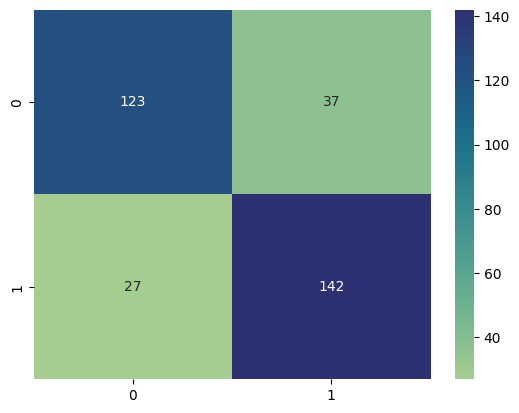

In [288]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, cmap='crest', annot=True, fmt='d');

In [290]:
f1_classification = f1_score(y_test, y_pred, average='macro')
f1_classification

0.8048201705598814

In [292]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       160
           1       0.79      0.84      0.82       169

    accuracy                           0.81       329
   macro avg       0.81      0.80      0.80       329
weighted avg       0.81      0.81      0.81       329



In [392]:
df_sample_clean.to_csv('qwen3_14b_labeling_clean_1000q.csv', index=False)

In [394]:
temp = df_test['question'].apply(lambda x : emoji.replace_emoji(x, ''))
df_test_clean = pd.DataFrame({'question' : temp, 'label' : y_test})

In [396]:
same_questions = pd.merge(df_sample_clean, df_test_clean, on='question', how='inner')
same_questions

,question,class,label_x,label_y
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1,1
1,"А вы первый раз подавали? Я повторно, просто",0,0,0
2,"А вы первый раз подавали? Я повторно, просто",0,0,0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0,0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста",1,1,1
...,...,...,...,...
101,В чей номер дала?,0,0,0
102,А если отклеится? Неудобно как-то получится,0,0,0
103,"Ольга, а не знаете кого в Убуде? Забыла эпилятор дома. Очень пора!",0,1,1
104,нашествие марсиан когда начнётся ? после убийства одного из босов ?,1,0,1


In [398]:
df_test_clean['label'].value_counts()

label
1    169
0    160
Name: count, dtype: int64

In [401]:
df_sample_clean['label'].value_counts()

label
1    551
0    449
Name: count, dtype: int64

In [415]:
temp = df_sample_clean[~df_sample_clean['question'].isin(df_test_clean['question'])]
temp.head()

,question,class,label
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0
6,"Привет, девочки!\nЕсть тут фотограф и оператор? Нужны для семейной фотосессии",1,1
8,"Девушки, кто недавно на ваилдбериз заказывал? Какая сейчас схема? Я заказываю доставку курьером и сразу оплачиваю онлайн, курьер все приносит и уходит. Я дома примеряю. Если что то не подошло, уношу в пункт выдачи и сдаю. Деньги мне приходят на счёт вб и я в последующем могу оплачивать ими покупки или перевести на карту. Так?",0,1
9,Зачем мне это? \nЭто плюсы для меня в твоей характеристике как-то добавляет?,1,0
11,"Девочки, сколько проходят симптомы ротовируса? Неделю уже понос, рвота периодически если пересосет (в общем не более 1-2 раз в сутки и понос 1 раз) ребёнку 1,4 г.. не ест больше ничего, вялая совсем.",1,1


In [423]:
df_sample_clean = df_sample_clean.drop(temp.index)

In [425]:
df_sample_clean.head()

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1
1,"А вы первый раз подавали? Я повторно, просто",0,0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста",1,1
5,"да нефтепродукты это, вы на заправке никогда не были? бензином краску с одежды никогда не смывали?",0,0


In [427]:
df_sample_clean.shape

(105, 3)

In [443]:
df_sample_ = df_sample_[~df_sample_['question'].isin(df_test['question'])]

In [445]:
df_sample_.shape

(895, 3)

In [449]:
df_sample_.head(-10)

,question,class,label
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0
6,"Привет, девочки!\nЕсть тут фотограф и оператор? Нужны для семейной фотосессии📸",1,1
8,"Девушки, кто недавно на ваилдбериз заказывал? Какая сейчас схема? Я заказываю доставку курьером и сразу оплачиваю онлайн, курьер все приносит и уходит. Я дома примеряю. Если что то не подошло, уношу в пункт выдачи и сдаю. Деньги мне приходят на счёт вб и я в последующем могу оплачивать ими покупки или перевести на карту. Так?",0,1
9,Зачем мне это? 🧐\nЭто плюсы для меня в твоей характеристике как-то добавляет?,1,0
11,"Девочки, сколько проходят симптомы ротовируса? Неделю уже понос, рвота периодически если пересосет (в общем не более 1-2 раз в сутки и понос 1 раз) ребёнку 1,4 г.. не ест больше ничего, вялая совсем.",1,1
...,...,...,...
985,"⚠️⚡️Кто-нибудь почувствовал скачок напряжения только что (минт 5 назад) ? 3к 3п лифты встали, света в корридоре нет 16 этаж",1,1
986,"Спасибо ) посмотрю. А сумма минимальная заказа какая ? Если сам забираешь ,то доставку уже не оплачиваешь ?",0,1
987,"Девочки, как гулять на улице без подгузника? Если ребенок просится - бежать искать кусты? 😂 Что-то сколько гуляем, пока не видела такого на дет.площадках",0,1
988,Кто такая стена? Я строю по приколу,1,0


In [455]:
val = df_sample_.loc[989, 'question']

In [459]:
matches = df[df['premise'] == val]

In [461]:
matches

,Unnamed: 0,premise,hypothesis,label,chat
15890,16048,"Девочки, выходить иди нет? Страшно ж(((","Не то что прям пригодилась, но ездила, и мужа тоже доставляла после корпоратива, щас иногда катаюсь, так чисто, ради практики)\nС ним тяжело, он сидит орет на меня вечно. А без него страшно. Да и надобности не было)\nНо стаж идет👍 😄",1,sling38
399633,403575,"Девочки, выходить иди нет? Страшно ж(((",У нас никогда никто их соседей не выходит.,0,sling38
614749,620781,"Девочки, выходить иди нет? Страшно ж(((","В класс маркете. Но что они мне не очень там понравились . и в сп брала, но ооосень давно, тут они качественней оказались",1,sling38


In [ ]:
df_sample_2 = sample_questions(df[15890], )

In [479]:
df.loc[15840:15891, 'premise']

15840                                                                                                                                                                                                                                                                                                                                                                Он спал просто
15841                                                                                                                                                                                                                                                                                                                В конкурсах на идеи новых Лего видела избушку на курьих ножках
15842    У меня в аптечке на случай аллергии фенистил гель, зодак и на крайний случай супрастин(его не даю без назначения врача) . Если что то не сильное, даю зодак....У знакомой у ребёнка 5-ти месяцев была аллергическая реакция на что то запрещенное в пит

In [485]:
df_sample_.tail()

,question,class,label
995,18.06.7? Блеать,1,0
996,Почему не должен? Я вроде не слышал ничего,1,0
997,"Интересно очень, сколько платите? Сколько занятий в неделю? В какое время?",1,0
998,"Девочки,перед д/садом ,что сдают соскоб или кал на я/г? Мне сказали соскоб,а подружка идет в эту же группу им кал.",1,1
999,На ЭКГ в 3 пк? Я записалась сегодня,1,0


In [487]:
matches = df[df['premise'] == 'На ЭКГ в 3 пк? Я записалась сегодня']
matches

,Unnamed: 0,premise,hypothesis,label,chat
16004,16163,На ЭКГ в 3 пк? Я записалась сегодня,"К Семёнову вполне спокойно можно попасть. И на дом его вызвать. А советуют, думаю, не потому, что модный он, а адекватный)",1,sling38


In [495]:
df_sample_2 = sample_questions(df.iloc[16004:, :], n=2000)

In [501]:
df_sample_2 = df_sample_2.reset_index(drop=True)
df_sample_2['label'] = np.nan
df_sample_2.head()

,question,class,label
0,На ЭКГ в 3 пк? Я записалась сегодня,1,NaN
1,Где сделать лазерную эпиляцию ? Спасибо,1,NaN
2,Дезинфекция. Сотрудники стали меньше болеть. Совпадение? - не знаю,1,NaN
3,1 к2 можно хоть какую то воду? Хоть ледяную хоть ржавую?🙏🏼,1,NaN
4,"админы ведь живут на гавайях? если нет, то смысла не вижу",0,NaN


In [505]:
df_sample_2 = classifier.classify_dataframe_batches(df_sample_2, model, batch_size=50)

qwen3-14b batch 400 - 450:  18%|█▊        | 9/50 [8:46:20<39:57:47, 3508.96s/it]

manual interrupt, return processed dataframe only


In [506]:
df_sample_2.to_csv('df_sample_2.csv', index=False)

In [509]:
df_sample_2

,question,class,label
0,На ЭКГ в 3 пк? Я записалась сегодня,1,0.0
1,Где сделать лазерную эпиляцию ? Спасибо,1,1.0
2,Дезинфекция. Сотрудники стали меньше болеть. Совпадение? - не знаю,1,1.0
3,1 к2 можно хоть какую то воду? Хоть ледяную хоть ржавую?🙏🏼,1,0.0
4,"админы ведь живут на гавайях? если нет, то смысла не вижу",0,0.0
...,...,...,...
1995,Может просто гуляют? Не вижу в этом ничего подозрительного,0,NaN
1996,"Думайте) только вы знаете все о своих возможностях. \nВы готовы терпеть убытки, проблемы, аллергии, траты денежные и временные ради мечты? Вперёд, ищите свою собаку. \n\nДумаете, что всегда можно отдать собаку обратно и вообще это животное, а не ребёнок? Тогда не надо пока заводить собаку. Животные не игрушки.",1,NaN
1997,"Привет) Подскажите пожалуйста, где можно взять платье в аренду на фотосессию? Спасибо ❤️",1,NaN
1998,"Добрый вечер) Девушки, где-то можно у нас купить так сказать чистые овощи? Малышу на прикорм",1,NaN


In [519]:
first_nan = df_sample_2[df_sample_2['label'].isna()]

In [521]:
first_nan

,question,class,label
409,"Девочки, в есть тут такие, кто хочется творить, снимать красивые видео и фото? Ищу креативных девчонок, с которыми можно снимать классный контент",1,NaN
410,"Девушки, где можно привиться от ковида после 18-00? Какой то кошмар, в двух ПК была, в одной до 3, во второй до 17",0,NaN
411,"Девочки, как вычистить молочные корки без ущерба для детиных волос? 😁А еще они у нас в области родничка! 😳",1,NaN
412,"А как тогда определять? Муж заболел в четверг, как ОРВИ, вчера пропал вкус и обоняние, мы с ним были в контакте два дня назад, потом уехали. Я не знаю когда ж мне теперь можно домой вернуться ( с детьми",1,NaN
413,Узнал новое слово? Красава! Не надо его пихать всюда,1,NaN
...,...,...,...
1995,Может просто гуляют? Не вижу в этом ничего подозрительного,0,NaN
1996,"Думайте) только вы знаете все о своих возможностях. \nВы готовы терпеть убытки, проблемы, аллергии, траты денежные и временные ради мечты? Вперёд, ищите свою собаку. \n\nДумаете, что всегда можно отдать собаку обратно и вообще это животное, а не ребёнок? Тогда не надо пока заводить собаку. Животные не игрушки.",1,NaN
1997,"Привет) Подскажите пожалуйста, где можно взять платье в аренду на фотосессию? Спасибо ❤️",1,NaN
1998,"Добрый вечер) Девушки, где-то можно у нас купить так сказать чистые овощи? Малышу на прикорм",1,NaN


In [527]:
df_sample_2 = classifier.classify_dataframe_batches(df_sample_2, model, batch_size=50)

qwen3-14b batch 1950 - 2000: 100%|██████████████| 50/50 [20:01<00:00, 24.03s/it]


In [529]:
df_sample_2.head()

,question,class,label
0,На ЭКГ в 3 пк? Я записалась сегодня,1,0.0
1,Где сделать лазерную эпиляцию ? Спасибо,1,1.0
2,Дезинфекция. Сотрудники стали меньше болеть. Совпадение? - не знаю,1,1.0
3,1 к2 можно хоть какую то воду? Хоть ледяную хоть ржавую?🙏🏼,1,0.0
4,"админы ведь живут на гавайях? если нет, то смысла не вижу",0,0.0


In [531]:
df_sample_2.to_csv('df_sample_2000.csv', index=False)

In [533]:
df_sample_2['label'] = df_sample_2['label'].astype('int64')
df_sample_2_clean = df_sample_2.copy()
df_sample_2_clean['question'] = df_sample_2_clean['question'].apply(lambda x : emoji.replace_emoji(x, ''))
df_sample_2_clean.head()

,question,class,label
0,На ЭКГ в 3 пк? Я записалась сегодня,1,0
1,Где сделать лазерную эпиляцию ? Спасибо,1,1
2,Дезинфекция. Сотрудники стали меньше болеть. Совпадение? - не знаю,1,1
3,1 к2 можно хоть какую то воду? Хоть ледяную хоть ржавую?,1,0
4,"админы ведь живут на гавайях? если нет, то смысла не вижу",0,0


In [535]:
df_sample_2_clean.to_csv('qwen3_14b_labeling_clean_2000q.csv', index=False)

In [561]:
df_sample_clean = pd.read_csv('data/qwen3_14b_labeling_clean_1000q.csv')
df_sample_clean.shape

(1000, 3)

In [567]:
df_sample_temp = df_sample_clean[~df_sample_clean['question'].isin(df_test['question'])]
df_sample_temp.shape

(912, 3)

In [569]:
df_sample_3000 = pd.concat([df_sample_temp, df_sample_2], ignore_index=True)
df_sample_3000.shape

(2912, 3)

In [577]:
df_sample_3000['question'].nunique()

2806

In [579]:
df_sample_3000.tail()

,question,class,label
2907,Может просто гуляют? Не вижу в этом ничего подозрительного,0,0
2908,"Думайте) только вы знаете все о своих возможностях. \nВы готовы терпеть убытки, проблемы, аллергии, траты денежные и временные ради мечты? Вперёд, ищите свою собаку. \n\nДумаете, что всегда можно отдать собаку обратно и вообще это животное, а не ребёнок? Тогда не надо пока заводить собаку. Животные не игрушки.",1,0
2909,"Привет) Подскажите пожалуйста, где можно взять платье в аренду на фотосессию? Спасибо ❤️",1,1
2910,"Добрый вечер) Девушки, где-то можно у нас купить так сказать чистые овощи? Малышу на прикорм",1,1
2911,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,1,1


In [587]:
val = df_sample_3000.loc[2911, 'question']

In [593]:
matches = df[df['premise'] == val]
matches

,Unnamed: 0,premise,hypothesis,label,chat
11704,11824,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,Недешевое удовольствие 😳 мне кажется в интернете полно информации по этой теме...🤔,1,sling38
47867,48386,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,"Нет такого понятия. Мы когда крестили, что старшего, что младшего, то священник сразу сказал, что дердит тот, у кого ребенок спокоен. Если с крестными нормально, то они, а если нет, то мама, желательно к купели чтобы крестные поднесли. И все.",0,sling38
163771,165412,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,"Девочки, кто-нибудь пользуется электрокачелей? Стоит брать?) Мы в гостях в ней всего 15 минут посидели, правда очень спокойно))",1,sling38
341060,344396,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,"На руках у мужа ребёнок был все время, а когда уже ходить у купели время пришло, святой водой облить, то крестный взял, потом опять супруг держал",0,sling38


In [603]:
df_sample_3 = sample_questions(df.iloc[47867:, :], n=300)
df_sample_3 = df_sample_3.reset_index(drop=True)
df_sample_3['label'] = np.nan

In [605]:
df_sample_3.head()

,question,class,label
0,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,1,NaN
1,"Доброе утро. Девушки, как считаете, можно ли дочу лечить тем же что и сына? Сыну почти 4 года, загноились глаза, прописали протирать раствором Фурацилина и капать ципролет. Сегодня у дочи почти 1.5 года тоже загноились глаза, пока только протираю.",0,NaN
2,В смысле писать? В полицию звоните.,1,NaN
3,"Отозвался - значит сам себя лишил водит.прав, минимум, на 1,5 года \nГде такие участники ДТП водятся? 😂",1,NaN
4,Ребёнок в коляске? Или как?) Мой просто вообще на спине не лежит( тоже пробовала так готовить),1,NaN


In [611]:
df_sample_3 = classifier.classify_dataframe_batches(df_sample_3, model, batch_size=50)

qwen3-14b batch 250 - 300: 100%|████████████████| 50/50 [26:40<00:00, 32.00s/it]


In [608]:
df_sample_3.head()

,question,class,label
0,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,1,1.0
1,"Доброе утро. Девушки, как считаете, можно ли дочу лечить тем же что и сына? Сыну почти 4 года, загноились глаза, прописали протирать раствором Фурацилина и капать ципролет. Сегодня у дочи почти 1.5 года тоже загноились глаза, пока только протираю.",0,1.0
2,В смысле писать? В полицию звоните.,1,0.0
3,"Отозвался - значит сам себя лишил водит.прав, минимум, на 1,5 года \nГде такие участники ДТП водятся? 😂",1,0.0
4,Ребёнок в коляске? Или как?) Мой просто вообще на спине не лежит( тоже пробовала так готовить),1,0.0


In [613]:
df_sample_3['label'] = df_sample_3['label'].astype('int64')
df_sample_3_clean = df_sample_3.copy()
df_sample_3_clean['question'] = df_sample_3_clean['question'].apply(lambda x : emoji.replace_emoji(x, ''))
df_sample_3_clean.head()

,question,class,label
0,На руках ведь всю церемонию должен быть ребёнок? У крестной или крестного?,1,1
1,"Доброе утро. Девушки, как считаете, можно ли дочу лечить тем же что и сына? Сыну почти 4 года, загноились глаза, прописали протирать раствором Фурацилина и капать ципролет. Сегодня у дочи почти 1.5 года тоже загноились глаза, пока только протираю.",0,1
2,В смысле писать? В полицию звоните.,1,0
3,"Отозвался - значит сам себя лишил водит.прав, минимум, на 1,5 года \nГде такие участники ДТП водятся?",1,0
4,Ребёнок в коляске? Или как?) Мой просто вообще на спине не лежит( тоже пробовала так готовить),1,0


In [615]:
df_sample_3_clean.to_csv('qwen3_14b_labeling_clean_300q.csv', index=False)

In [617]:
df_sample_temp = df_sample_3_clean[~df_sample_3_clean['question'].isin(df_test['question'])]
df_sample_temp.shape

(299, 3)

In [619]:
df_sample_3000 = pd.concat([df_sample_temp, df_sample_3000], ignore_index=True)
df_sample_3000.shape

(3211, 3)

In [621]:
df_sample_3000.loc[:, 'question'].nunique()

3082

In [625]:
df_sample_3000.drop_duplicates(subset=['question'])
df_sample_3000.shape

(3211, 3)

In [633]:
df_sample_3000.to_csv('qwen3_14b_labeling_clean_3211q.csv', index=False)

In [677]:
df_sample_3211 = pd.read_csv('data/qwen3_14b_labeling_clean_3211q.csv')

In [687]:
df_sample_temp = df_sample_3211[~df_sample_3211['question'].isin(df_test['question'])]
df_sample_temp.shape

(3205, 3)

In [693]:
df_sample_temp.to_csv('qwen3_14b_labeling_clean_3205q.csv', index=False)

In [9]:
df_sample_3025 = pd.read_csv('data/qwen3_14b_labeling_clean_3205q.csv')

In [11]:
vectorizer = CountVectorizer(analyzer='word')
X = vectorizer.fit_transform(df_sample_3025['question'])
y = df_sample_3025['label']

log_reg = LogisticRegression(penalty='l2', C=1.0, random_state=42, solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42)

In [17]:
df_test = pd.read_csv('data/gold_manual_anno.csv')
X_test, y_test = df_test['question'], df_test['final']
X_test = df_test['question'].apply(lambda x : emoji.replace_emoji(x, ''))

X_test = vectorizer.transform(X_test)
y_pred = log_reg.predict(X_test)

### Test model

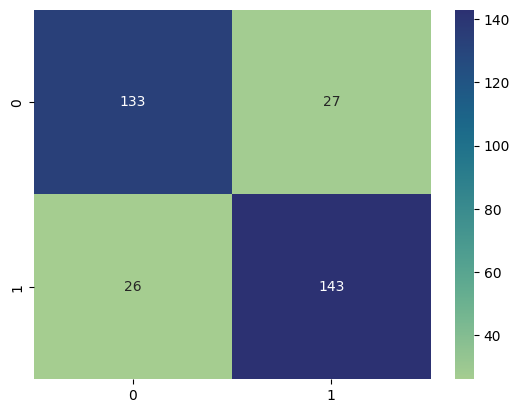

In [19]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, cmap='crest', annot=True, fmt='d');

In [21]:
f1_classification = f1_score(y_test, y_pred, average='macro')
f1_classification

0.8387568082410927

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       160
           1       0.84      0.85      0.84       169

    accuracy                           0.84       329
   macro avg       0.84      0.84      0.84       329
weighted avg       0.84      0.84      0.84       329



### Download trained model + test

In [25]:
with open('log_regression_model.pkl', 'wb') as file:
    pickle.dump(log_reg, file)
    

In [37]:
with open('log_regression_model.pkl', 'rb') as file:
    clf = pickle.load(file)

In [41]:
y_pred_ = clf.predict(X_test)
f1_classification = f1_score(y_test, y_pred_, average='macro')
f1_classification

0.8387568082410927

In [13]:
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)